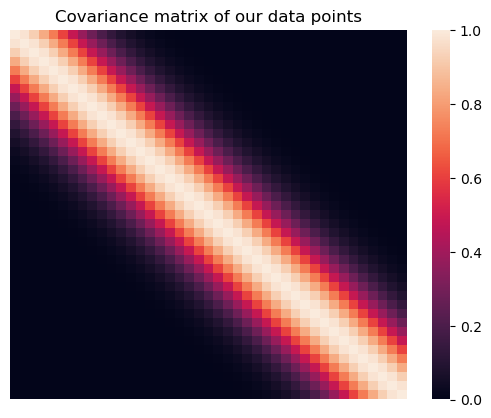

In [70]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.spatial
import seaborn as sns

# Define the exponentiated quadratic 
def exponentiated_quadratic(xa, xb):
    """Exponentiated quadratic  with σ=1"""
    # L2 distance (Squared Euclidian)
    sq_norm = -0.5 * scipy.spatial.distance.cdist(xa, xb, 'sqeuclidean')
    return np.exp(sq_norm)

# Sample from the Gaussian process distribution
nb_of_samples = 41  # Number of points in each function
number_of_functions = 5  # Number of functions to sample
# Independent variable samples
X = np.expand_dims(np.linspace(-4, 4, nb_of_samples), 1)
Σ = exponentiated_quadratic(X, X)  # Kernel of data points

# Draw samples from the prior at our data points.
# Assume a mean of 0 for simplicity
ys = np.random.multivariate_normal(
    mean=np.zeros(nb_of_samples), cov=Σ, 
    size=number_of_functions)

# Plot heatmap of the covariance matrix using sns
sns.heatmap(Σ, xticklabels=False, yticklabels=False)
plt.title('Covariance matrix of our data points')
plt.show()




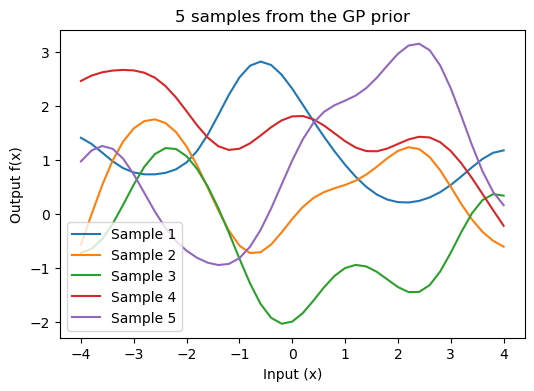

In [71]:
# Plot the sampled functions
plt.figure(figsize=(6, 4))
for i in range(number_of_functions):
    plt.plot(X, ys[i], label=f'Sample {i+1}')
plt.xlabel('Input (x)')
plt.ylabel('Output f(x)')
plt.title('5 samples from the GP prior')
plt.legend()
plt.show()


In [72]:
# Gaussian process posterior
def GP(X1, y1, X2, kernel_func):
    """
    Calculate the posterior mean and covariance matrix for y2
    based on the corresponding input X2, the observations (y1, X1), 
    and the prior kernel function.
    """
    # Kernel of the observations
    Σ11 = kernel_func(X1, X1)
    # Kernel of observations vs to-predict
    Σ12 = kernel_func(X1, X2)
    # Solve
    solved = scipy.linalg.solve(Σ11, Σ12, assume_a='pos').T
    # Compute posterior mean
    μ2 = solved @ y1
    # Compute the posterior covariance
    Σ22 = kernel_func(X2, X2)
    Σ2 = Σ22 - (solved @ Σ12)
    return μ2, Σ2  # mean, covariance

In [73]:
# Compute the posterior mean and covariance

# Define the true function that we want to regress on
f_sin = lambda x: (np.sin(x)).flatten()

n1 = 8  # Number of points to condition on (training points)
n2 = 75  # Number of points in posterior (test points)
ny = 5  # Number of functions that will be sampled from the posterior
domain = (-6, 6)

# Sample observations (X1, y1) on the function
X1 = np.random.uniform(domain[0]+2, domain[1]-2, size=(n1, 1))
y1 = f_sin(X1)
# Predict points at uniform spacing to capture function
X2 = np.linspace(domain[0], domain[1], n2).reshape(-1, 1)
# Compute posterior mean and covariance
μ2, Σ2 = GP(X1, y1, X2, exponentiated_quadratic)
# Compute the standard deviation at the test points to be plotted
σ2 = np.sqrt(np.diag(Σ2))

# Draw some samples of the posterior
y2 = np.random.multivariate_normal(mean=μ2, cov=Σ2, size=ny)
y2.shape


(5, 75)

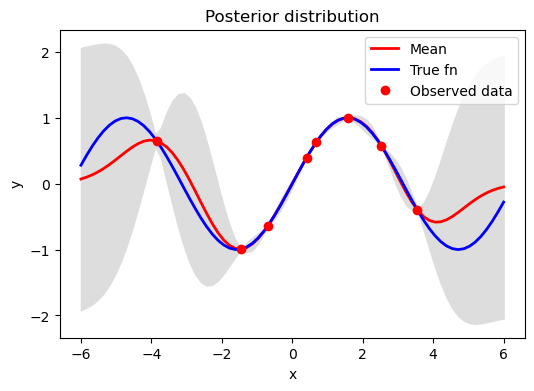

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


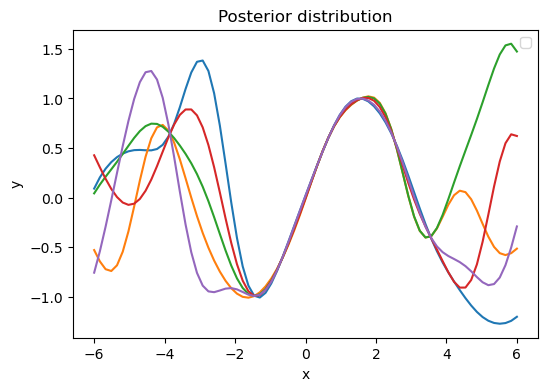

In [74]:
# Plot the postior
plt.figure(figsize=(6, 4))
plt.gca().fill_between(X2.flat, μ2-2*σ2, μ2+2*σ2, color="#dddddd")
plt.plot(X2, μ2, 'r', lw=2, label='Mean') # Mean prediction 
# for i in range(ny):
#     plt.plot(X2, y2[i], 'k', lw=0.5) # Sampled functions
# plot true function
plt.plot(X2, f_sin(X2), 'b', lw=2, label='True fn')
plt.plot(X1, y1, 'ro', label='Observed data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Posterior distribution')
plt.legend()
plt.show()

# Plot the true function and the sampled functions
plt.figure(figsize=(6, 4))
# plt.plot(X2, f_sin(X2), 'b', lw=2, label='True fn')
for i in range(ny):
    plt.plot(X2, y2[i])
# plt.plot(X1, y1, 'ro', label='Observed data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Posterior distribution')
plt.legend()
plt.show()


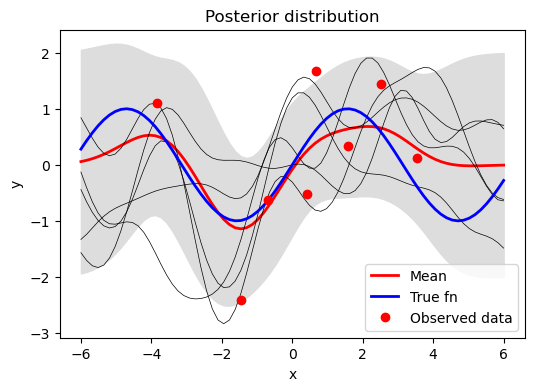

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


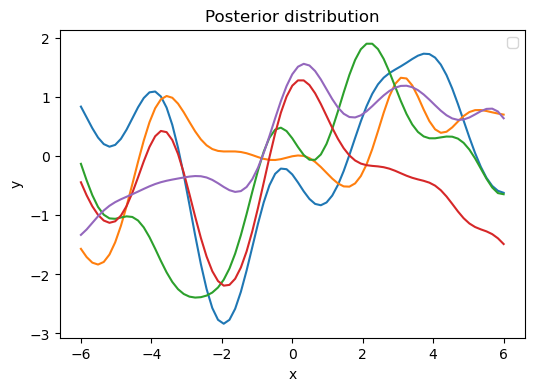

In [75]:
# Gaussian process posterior with noisy obeservations
def GP_noise(X1, y1, X2, kernel_func, σ_noise):
    """
    Calculate the posterior mean and covariance matrix for y2
    based on the corresponding input X2, the noisy observations 
    (y1, X1), and the prior kernel function.
    """
    # Kernel of the noisy observations
    Σ11 = kernel_func(X1, X1) + ((σ_noise ** 2) * np.eye(n1))
    # Kernel of observations vs to-predict
    Σ12 = kernel_func(X1, X2)
    # Solve
    solved = scipy.linalg.solve(Σ11, Σ12, assume_a='pos').T
    # Compute posterior mean
    μ2 = solved @ y1
    # Compute the posterior covariance
    Σ22 = kernel_func(X2, X2)
    Σ2 = Σ22 - (solved @ Σ12)
    return μ2, Σ2  # mean, covariance
# Compute the posterior mean and covariance

σ_noise = 1.  # The standard deviation of the noise
# Add noise kernel to the samples we sampled previously
y1 = y1 + ((σ_noise ** 2) * np.random.randn(n1))

# Compute posterior mean and covariance
μ2, Σ2 = GP_noise(X1, y1, X2, exponentiated_quadratic, σ_noise)
# Compute the standard deviation at the test points to be plotted
σ2 = np.sqrt(np.diag(Σ2))

# Draw some samples of the posterior
y2 = np.random.multivariate_normal(mean=μ2, cov=Σ2, size=ny)

# Plot the postior
plt.figure(figsize=(6, 4))
plt.gca().fill_between(X2.flat, μ2-2*σ2, μ2+2*σ2, color="#dddddd")
plt.plot(X2, μ2, 'r', lw=2, label='Mean') # Mean prediction
for i in range(ny):
    plt.plot(X2, y2[i], 'k', lw=0.5) # Sampled functions
# plot true function
plt.plot(X2, f_sin(X2), 'b', lw=2, label='True fn')
plt.plot(X1, y1, 'ro', label='Observed data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Posterior distribution')
plt.legend()
plt.show()

# Plot the true function and the sampled functions
plt.figure(figsize=(6, 4))
# plt.plot(X2, f_sin(X2), 'b', lw=2, label='True fn')
for i in range(ny):
    plt.plot(X2, y2[i])
# plt.plot(X1, y1, 'ro', label='Observed data')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Posterior distribution')
plt.legend()
plt.show()


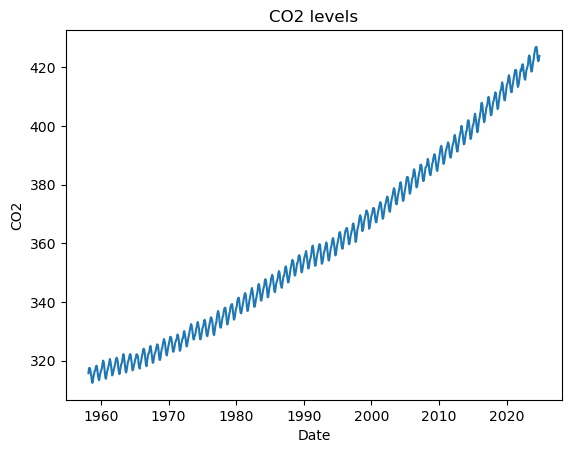

In [102]:
import pandas as pd

co2_df = pd.read_csv('MLO/MaunaLaoCO2.csv')
co2_df['Date'] = pd.to_datetime(co2_df['Date'])
co2_df['Year'] = co2_df['Date'].dt.year


plt.plot(co2_df['Date'], co2_df['CO2'])
plt.xlabel('Date')
plt.ylabel('CO2')
plt.title('CO2 levels')
plt.show()

622 measurements in the observed set
179 measurements in the test set


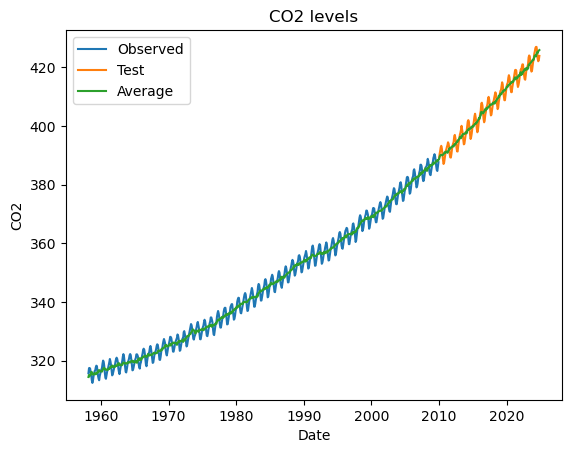

In [127]:
date_split_predict = 2010
df_observed = co2_df[co2_df['Year'] < date_split_predict]
print('{} measurements in the observed set'.format(len(df_observed)))
df_predict = co2_df[co2_df['Year'] >= date_split_predict]
print('{} measurements in the test set'.format(len(df_predict)))

# plot the observed and test set
plt.plot(df_observed['Date'], df_observed['CO2'], label='Observed')
plt.plot(df_predict['Date'], df_predict['CO2'], label='Test')
plt.plot(co2_df['Date'], co2_df['Average'], label='Average')
plt.xlabel('Date')
plt.ylabel('CO2')
plt.title('CO2 levels')
plt.legend()
plt.show()


In [135]:
# Compute the mean and standard deviation of the observed set
observations_mean = torch.tensor(
    [np.mean(df_observed["CO2"].values)], dtype=torch.float64)
mean_fn = lambda _: observations_mean

import torch
import torch.nn as nn
import torch.nn.functional as F

class GPKernel(nn.Module):
    def __init__(self):
        super().__init__()
        
        # Initialize parameters (trainable variables)
        self.smooth_amplitude = nn.Parameter(torch.tensor(10.0, dtype=torch.float64))
        self.smooth_length_scale = nn.Parameter(torch.tensor(10.0, dtype=torch.float64))
        
        self.periodic_amplitude = nn.Parameter(torch.tensor(5.0, dtype=torch.float64))
        self.periodic_length_scale = nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        self.periodic_period = nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        self.periodic_local_length_scale = nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        
        self.irregular_amplitude = nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        self.irregular_length_scale = nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        self.irregular_scale_mixture = nn.Parameter(torch.tensor(1.0, dtype=torch.float64))
        
        self.observation_noise_variance = nn.Parameter(torch.tensor(1.0, dtype=torch.float64))

    def forward(self):
        # Apply transformations to enforce positivity
        smooth_amplitude = torch.exp(self.smooth_amplitude)
        smooth_length_scale = torch.exp(self.smooth_length_scale)
        
        periodic_amplitude = torch.exp(self.periodic_amplitude)
        periodic_length_scale = torch.exp(self.periodic_length_scale)
        periodic_period = torch.exp(self.periodic_period)
        periodic_local_length_scale = torch.exp(self.periodic_local_length_scale)
        
        irregular_amplitude = torch.exp(self.irregular_amplitude)
        irregular_length_scale = torch.exp(self.irregular_length_scale)
        irregular_scale_mixture = torch.exp(self.irregular_scale_mixture)
        
        observation_noise_variance = torch.exp(self.observation_noise_variance)

        # Define kernels
        smooth_kernel = smooth_amplitude * torch.exp(
            -0.5 * (1.0 / smooth_length_scale) ** 2
        )
        
        periodic_kernel = (
            periodic_amplitude *
            torch.exp(
                -2 * (torch.sin(torch.pi * periodic_period) / periodic_length_scale) ** 2
            ) *
            torch.exp(-0.5 * (1.0 / periodic_local_length_scale) ** 2)
        )
        
        irregular_kernel = irregular_amplitude * (
            1 + (1.0 / irregular_length_scale) ** 2
        ) ** (-irregular_scale_mixture)
        
        return {
            "smooth_kernel": smooth_kernel,
            "periodic_kernel": periodic_kernel,
            "irregular_kernel": irregular_kernel,
            "observation_noise_variance": observation_noise_variance,
        }

# Instantiate the model
model = GPKernel()

# List trainable parameters
trainable_parameters = list(model.parameters())
print("Trainable parameters:", trainable_parameters)


import torch
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

import numpy as np

# Convert datetime64 to float (timestamps)
df_date = torch.tensor(
    df_observed["Date"].astype(np.int64).values, dtype=torch.float64
).unsqueeze(1)
df_co2 = torch.tensor(df_observed["CO2"].values, dtype=torch.float64)

# Dataset and DataLoader for batching
batch_size = 128
dataset = TensorDataset(df_date, df_co2)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Define Gaussian Process negative log likelihood
def gp_loss_fn(index_points, observations, model):
    """
    Gaussian process negative-log-likelihood loss function.
    """
    # Instantiate Gaussian process with given parameters
    kernel_outputs = model()  # Retrieve kernels and noise variance
    smooth_kernel = kernel_outputs["smooth_kernel"]
    periodic_kernel = kernel_outputs["periodic_kernel"]
    irregular_kernel = kernel_outputs["irregular_kernel"]
    observation_noise_variance = kernel_outputs["observation_noise_variance"]

    kernel = smooth_kernel + periodic_kernel + irregular_kernel

    # Kernel matrix and add noise
    K = kernel + torch.eye(index_points.shape[0], dtype=torch.float64) * observation_noise_variance
    L = torch.linalg.cholesky(K)

    # Compute NLL
    y = observations.unsqueeze(1)
    alpha = torch.cholesky_solve(y, L)
    nll = 0.5 * torch.sum(y * alpha) + torch.sum(torch.log(torch.diag(L))) + 0.5 * len(y) * torch.log(torch.tensor(2 * torch.pi))
    return nll

# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Training loop
batch_nlls = []  # Batch NLL for plotting
full_ll = []  # Full data NLL for plotting
nb_iterations = 10001

for i in tqdm(range(nb_iterations)):
    for index_points_batch, observations_batch in dataloader:
        # Run optimization for a single batch
        optimizer.zero_grad()
        loss = gp_loss_fn(index_points_batch, observations_batch, model)
        loss.backward()
        optimizer.step()
        batch_nlls.append((i, loss.item()))
    
    # Evaluate on all observations every 100 iterations
    if i % 100 == 0:
        with torch.no_grad():
            full_loss = gp_loss_fn(df_date, df_co2, model)
            full_ll.append((i, full_loss.item()))


Trainable parameters: [Parameter containing:
tensor(10., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(10., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(5., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(1., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(1., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(1., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(1., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(1., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(1., dtype=torch.float64, requires_grad=True), Parameter containing:
tensor(1., dtype=torch.float64, requires_grad=True)]


100%|██████████| 10001/10001 [01:00<00:00, 163.97it/s]


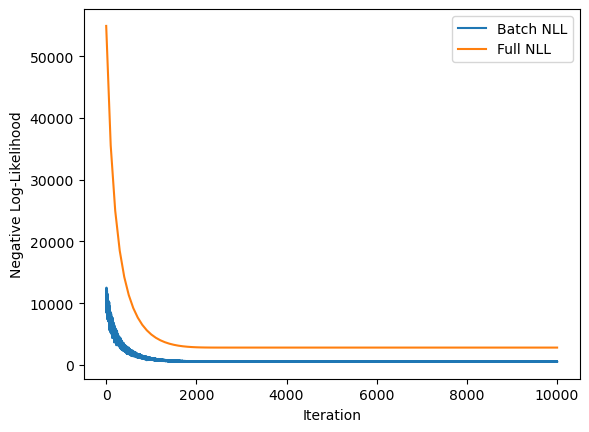

In [136]:
# Plot the negative log-likelihood
batch_nlls = np.array(batch_nlls)
full_ll = np.array(full_ll)

plt.plot(batch_nlls[:, 0], batch_nlls[:, 1], label="Batch NLL")
plt.plot(full_ll[:, 0], full_ll[:, 1], label="Full NLL")
plt.xlabel("Iteration")
plt.ylabel("Negative Log-Likelihood")
plt.legend()
plt.show()


In [144]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def gp_posterior_predict(
    kernel, observation_noise_variance, index_points, 
    observation_index_points, observations
):
    # Kernel matrix for observations
    K = kernel(observation_index_points, observation_index_points)
    # Add noise to diagonal with broadcasting
    K += torch.eye(K.size(0), dtype=torch.float64) * observation_noise_variance.expand_as(torch.eye(K.size(0), dtype=torch.float64))

    # Cholesky decomposition
    L = torch.linalg.cholesky(K)

    # Cross kernel matrix
    K_s = kernel(observation_index_points, index_points)

    # Kernel matrix for new points
    K_ss = kernel(index_points, index_points)
    K_ss += torch.eye(K_ss.size(0), dtype=torch.float64) * 1e-6  # Stabilization term

    # Compute mean and covariance of posterior
    alpha = torch.cholesky_solve(observations.unsqueeze(1), L)
    posterior_mean = K_s.T @ alpha
    v = torch.linalg.solve(L, K_s)
    posterior_cov = K_ss - v.T @ v
    posterior_std = torch.sqrt(torch.diag(posterior_cov))

    return posterior_mean.squeeze(), posterior_std.squeeze()


# Compute posterior predictions
index_points = torch.tensor(
    df_predict["Date"].astype(np.int64).values, dtype=torch.float64
).unsqueeze(1)
observation_index_points = torch.tensor(
    df_observed["Date"].astype(np.int64).values, dtype=torch.float64
).unsqueeze(1)
observations = torch.tensor(df_observed["CO2"].values, dtype=torch.float64)

# Assuming the `model` class provides the kernel and observation noise variance
kernel_outputs = model()
kernel = lambda x1, x2: (
    kernel_outputs["smooth_kernel"]
    + kernel_outputs["periodic_kernel"]
    + kernel_outputs["irregular_kernel"]
)
observation_noise_variance = kernel_outputs["observation_noise_variance"]

posterior_mean, posterior_std = gp_posterior_predict(
    kernel, observation_noise_variance, index_points, 
    observation_index_points, observations
)

# Plot posterior predictions
μ = posterior_mean.detach().numpy()
σ = posterior_std.detach().numpy()
dates_predict = df_predict["Date"].astype(np.int64).values
dates_observed = df_observed["Date"].astype(np.int64).values

plt.figure(figsize=(12, 6))
plt.plot(dates_observed, df_observed["CO2"].values, 'o', label='True Data', markersize=3)
plt.plot(dates_predict, μ, label='Predicted Mean (μ)', color='red')
plt.fill_between(
    dates_predict,
    μ - 2 * σ,
    μ + 2 * σ,
    color='red',
    alpha=0.3,
    label='95% Prediction Interval (2σ)'
)
plt.xlabel('Date')
plt.ylabel('CO₂ (ppm)')
plt.title('Posterior Predictions Conditioned on Observations Before 2010')
plt.legend()
plt.grid(True)
plt.show()


IndexError: Dimension specified as 0 but tensor has no dimensions

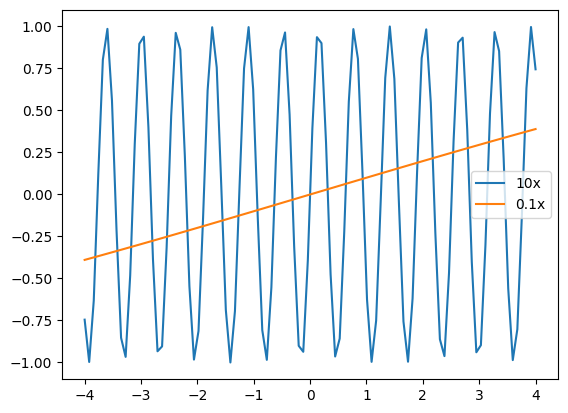

In [1]:
import matplotlib.pyplot as plt
import numpy as np
x = np.linspace(-4,4,100)

plt.figure()
plt.plot(x, np.sin(10*x), label="10x")
plt.plot(x, np.sin(0.1*x), label="0.1x")
plt.legend()

